In [1]:
from google.colab import files
uploaded=files.upload()

Saving iris.data to iris.data


In [2]:
import pandas as pd

In [5]:
df = pd.read_csv("iris.data", header=None)

df.head(20)

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [6]:
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0


In [7]:
import argparse
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [8]:
X = df.iloc[:, :-1].values

In [10]:
X[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [11]:
from scipy.spatial.distance import pdist,squareform
dist_matrix=squareform(pdist(X,metric='euclidean'))

In [13]:
mst=minimum_spanning_tree(dist_matrix).toarray()

In [37]:
k = 3
edges = []
n = mst.shape[0]

for i in range(n):
    for j in range(i+1, n):
        if mst[i][j] > 0:
            edges.append((i, j, mst[i][j]))

edges = sorted(edges, key=lambda x: x[2], reverse=True)

for i in range(k - 1):
    u, v, w = edges[i]
    mst[u][v] = 0
    mst[v][u] = 0

In [38]:
visited = [False]*n
labels = [-1]*n
cluster_id = 0

def dfs(node):
    stack = [node]
    while stack:
        curr = stack.pop()
        if not visited[curr]:
            visited[curr] = True
            labels[curr] = cluster_id
            for neighbor in range(n):
                if mst[curr][neighbor] > 0 and not visited[neighbor]:
                    stack.append(neighbor)

for i in range(n):
    if not visited[i]:
        dfs(i)
        cluster_id += 1

In [39]:
mst = mst + mst.T

In [40]:
mst = minimum_spanning_tree(dist_matrix).toarray()
mst = mst + mst.T

In [41]:
print(len(set(labels)))

3


In [42]:
import collections
print(collections.Counter(labels))

Counter({1: 98, 0: 50, 2: 2})


In [43]:
import pandas as pd

pd.DataFrame({
    "SampleId": range(n),
    "ClusterLabel": labels
}).to_csv("mst_clusters.csv", index=False)

In [44]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

pd.DataFrame({
    "SampleId": range(n),
    "ClusterLabel": kmeans_labels
}).to_csv("kmeans_clusters.csv", index=False)

In [45]:
from sklearn.metrics import silhouette_score

mst_score = silhouette_score(X, labels)
kmeans_score = silhouette_score(X, kmeans_labels)

print("MST Silhouette Score:", mst_score)
print("KMeans Silhouette Score:", kmeans_score)


MST Silhouette Score: 0.5118387098922373
KMeans Silhouette Score: 0.5509643746707443


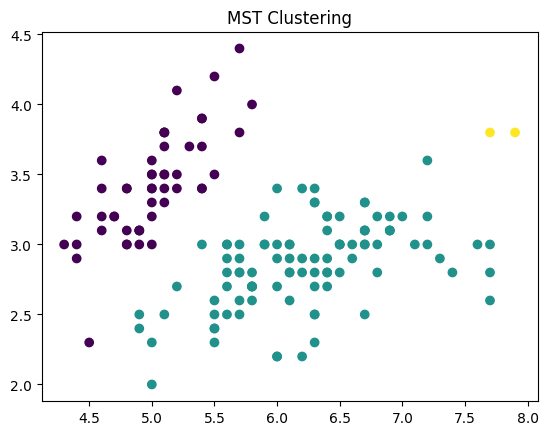

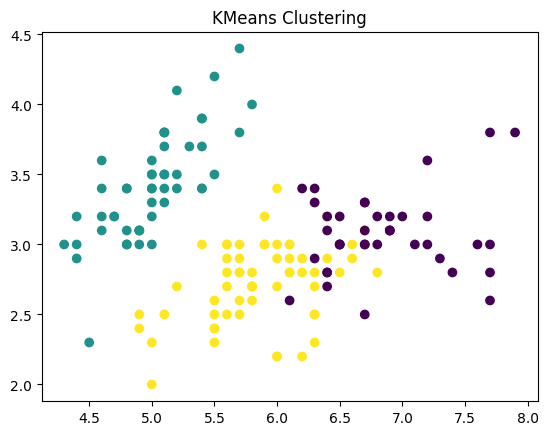

In [46]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.title("MST Clustering")
plt.show()

plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels)
plt.title("KMeans Clustering")
plt.show()

In [47]:
import cv2

In [48]:
from google.colab import files
uploaded=files.upload()

Saving Screenshot 2026-03-19 141404.png to Screenshot 2026-03-19 141404.png


In [50]:
from google.colab.patches import cv2_imshow

In [57]:
img=cv2.imread('Screenshot 2026-03-19 141404.png')

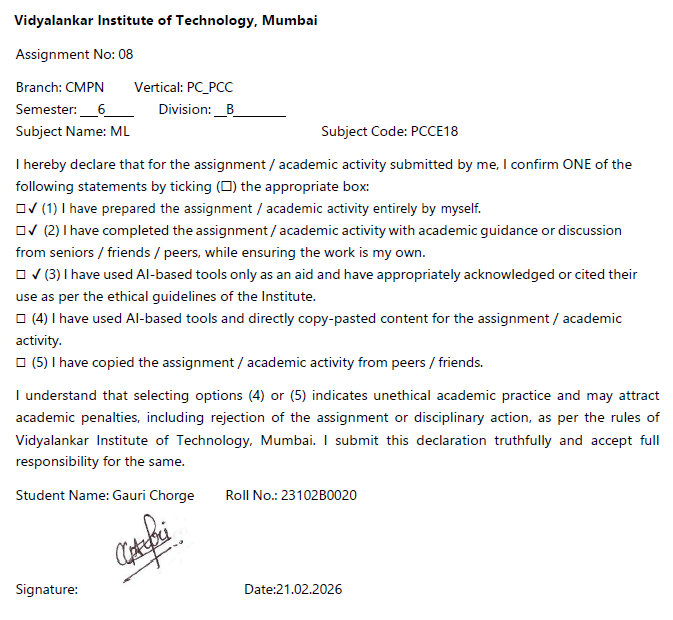

In [58]:
cv2_imshow(img)